In [ ]:
# Install required libraries
!pip install datasets evaluate rouge_score transformers accelerate


[notice] A new release of pip is available: 23.3.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [ ]:
!pip install matplotlib


[notice] A new release of pip is available: 23.3.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [ ]:
# Import necessary modules
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoProcessor, Trainer, TrainingArguments
import torch
import os
import evaluate
import numpy as np
import matplotlib.pyplot as plt
import random
from huggingface_hub import login
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"


In [ ]:
# Set offline mode for wandb (comment out if you want to log to W&B)
os.environ["WANDB_MODE"] = "offline"


# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Using device: cuda


In [ ]:
!pip install einops timm


[notice] A new release of pip is available: 23.3.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [ ]:

print("Loading Florence-2 model and processor...")
# Load Florence-2 model
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Florence-2-base-ft",
    trust_remote_code=True
).to(device)

Loading Florence-2 model and processor...


/usr/local/lib/python3.10/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Florence2LanguageForConditionalGeneration has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise y

In [ ]:
# Freeze vision tower parameters for efficiency
print("Freezing vision tower parameters...")
for param in model.vision_tower.parameters():
    param.requires_grad = False
# Load processor
processor = AutoProcessor.from_pretrained(
    "microsoft/Florence-2-base-ft",
    trust_remote_code=True
)

print("Loading Kvasir-VQA dataset...")
# Load dataset
ds = load_dataset("SimulaMet-HOST/Kvasir-VQA")['raw']

Freezing vision tower parameters...
Loading Kvasir-VQA dataset...


Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
# For full training, use a larger portion of the dataset
# For this implementation, we'll use a smaller portion for demonstration
USE_FULL_DATASET = True  # Set to True for full training

if USE_FULL_DATASET:
    # Use 80% of data for training, 20% for validation
    dataset = ds.train_test_split(test_size=0.2, seed=RANDOM_SEED)
    train_dataset, val_dataset = dataset['train'], dataset['test']
else:
    # Use a smaller subset for faster experimentation
    dataset = ds.train_test_split(test_size=0.10, seed=RANDOM_SEED)  # Use 5% of total data
    dataset = dataset['test'].train_test_split(test_size=0.2, seed=RANDOM_SEED)  # Split into train and validation
    train_dataset, val_dataset = dataset['train'], dataset['test']

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 47079
Validation dataset size: 11770


In [ ]:
def collate_fn(batch):
    """Process images and questions into tensors suitable for the model."""
    questions = [f"<MedVQA>{x['question']}" for x in batch]
    images = [x["image"].convert("RGB") if x["image"].mode != "RGB" else x["image"] for x in batch]
    answers = [x["answer"] for x in batch]

    inputs = processor(text=questions, images=images, return_tensors="pt", padding=True)
    labels = processor.tokenizer(answers, return_tensors="pt", padding=True).input_ids
    labels[labels == processor.tokenizer.pad_token_id] = -100
    inputs["labels"] = labels
    return inputs

# Load evaluation metrics
bleu, meteor, rouge = map(evaluate.load, ["bleu", "meteor", "rouge"])

def compute_metrics(eval_pred):
    """Compute NLP metrics for model evaluation."""
    preds, labels = eval_pred
    preds = processor.tokenizer.batch_decode(np.argmax(preds[0], axis=-1), skip_special_tokens=True)
    labels = processor.tokenizer.batch_decode(
        np.where(labels != -100, labels, processor.tokenizer.pad_token_id),
        skip_special_tokens=True
    )
    preds, labels = [p.strip() for p in preds], [l.strip() for l in labels]

    return {
        "bleu": bleu.compute(predictions=preds, references=[[l] for l in labels])["bleu"],
        "meteor": meteor.compute(predictions=preds, references=labels)["meteor"],
        "rougeL": rouge.compute(predictions=preds, references=labels)["rougeL"],
    }


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
from transformers import TrainingArguments, EarlyStoppingCallback

BATCH_SIZE = 4 if torch.cuda.is_available() else 2
NUM_EPOCHS = 10
MODEL_NAME = "Florence-2-full-finetune"

print(f"Setting up training with batch size: {BATCH_SIZE}, epochs: {NUM_EPOCHS}")

training_args = TrainingArguments(
    output_dir=f"./{MODEL_NAME}",
    per_device_train_batch_size=2,           # Lowered for safety
    per_device_eval_batch_size=1,            # Key fix
    num_train_epochs=NUM_EPOCHS,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    save_strategy="steps",
    save_steps=1000,
    eval_strategy="steps",
    eval_steps=1000,
    load_best_model_at_end=True,
   metric_for_best_model="eval_loss",
    prediction_loss_only=True,               # <- Key fix
    report_to=[],
    save_total_limit=2,
    remove_unused_columns=False,
    fp16=True,
    gradient_accumulation_steps=8,
    warmup_steps=200,
    lr_scheduler_type="cosine",
    dataloader_num_workers=4
)


Setting up training with batch size: 4, epochs: 10


In [ ]:
#!pip install wandb
#!pip install --upgrade typing_extensions
#!pip install --upgrade wandb pydantic transformers
!pip install --upgrade typing_extensions


[notice] A new release of pip is available: 23.3.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [ ]:
# Monkey-patch PIL.Image to fix ExifTags access issue
import PIL.Image
import PIL.ExifTags

PIL.Image.ExifTags = PIL.ExifTags


In [ ]:
from transformers import Trainer, EarlyStoppingCallback

print("Initializing trainer and starting training...")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    compute_metrics=None  # ← Set this to None during training
)

import torch
torch.cuda.empty_cache()
# Start training
trainer.train()

Initializing trainer and starting training...


Step,Training Loss,Validation Loss
1000,0.096100,0.106701
2000,0.111500,0.107509
3000,0.085200,0.103044
4000,0.085300,0.090986
5000,0.094000,0.081787
6000,0.069500,0.084895
7000,0.083500,0.084308
8000,0.076200,0.081615
9000,0.072200,0.082154
10000,0.068200,0.086042


There were missing keys in the checkpoint model loaded: ['language_model.model.encoder.embed_tokens.weight', 'language_model.model.decoder.embed_tokens.weight'].


TrainOutput(global_step=11000, training_loss=0.08920301387526772, metrics={'train_runtime': 7939.546, 'train_samples_per_second': 59.297, 'train_steps_per_second': 3.706, 'total_flos': 4563162092743680.0, 'train_loss': 0.08920301387526772, 'epoch': 3.7378079864061173})

In [ ]:
trainer.compute_metrics = compute_metrics
metrics = trainer.evaluate()
print(metrics)

{'eval_loss': 0.08161524683237076, 'eval_runtime': 294.3027, 'eval_samples_per_second': 39.993, 'eval_steps_per_second': 39.993, 'epoch': 3.7378079864061173}


In [ ]:
model.save_pretrained("./Florence-2-full-finetune/final")
from huggingface_hub import login
login()
model.push_to_hub("Florence-2-full-finetune")
processor.push_to_hub("Florence-2-full-finetune")

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/sageofai/Florence-2-full-finetune/commit/4c19de5799db9baca2db05d26291595f9ae72cc1', commit_message='Upload processor', commit_description='', oid='4c19de5799db9baca2db05d26291595f9ae72cc1', pr_url=None, repo_url=RepoUrl('https://huggingface.co/sageofai/Florence-2-full-finetune', endpoint='https://huggingface.co', repo_type='model', repo_id='sageofai/Florence-2-full-finetune'), pr_revision=None, pr_num=None)

In [ ]:
# Use your model repo name instead of SushantGautam/Florence-2-vqa-demo
model_hf = AutoModelForCausalLM.from_pretrained("sageofai/Florence-2-full-finetune", trust_remote_code=True).to(device)
## change needed in uploaded config.json on HuggingFace: LINE 165, "model_type": "" --> "model_type": "davit

config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.08G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/292 [00:00<?, ?B/s]

Q: Where in the image is the abnormality?
Model: lower-center; lower-right
GT: center; center-right; lower-center; lower-right; upper-center; upper-right


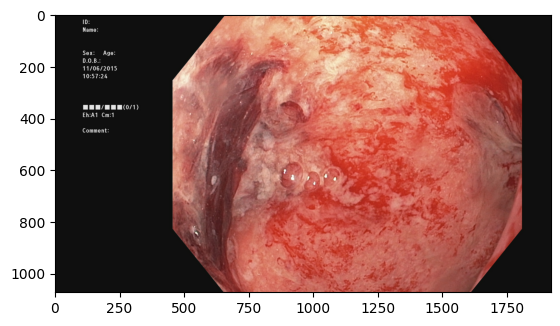

In [ ]:
# ReRun this block to generate for new ramdom sample
import random
sample = [val_dataset[random.randint(0, len(val_dataset)-1)]] # rerun this block to generate new sample
import matplotlib.pyplot as plt; plt.imshow(sample[0]['image'])
inputs = collate_fn(sample)
inputs = {k: v.to(device) for k, v in inputs.items() if k not in ['labels', 'attention_mask']}

with torch.no_grad():
    output = model_hf.generate(**inputs)

print(f"Q: {sample[0]['question']}\nModel: {processor.tokenizer.decode(output[0], skip_special_tokens=True)}\nGT: {sample[0]['answer']}")

Q: Are there any instruments in the image? Check all that are present.
Model: none
GT: none


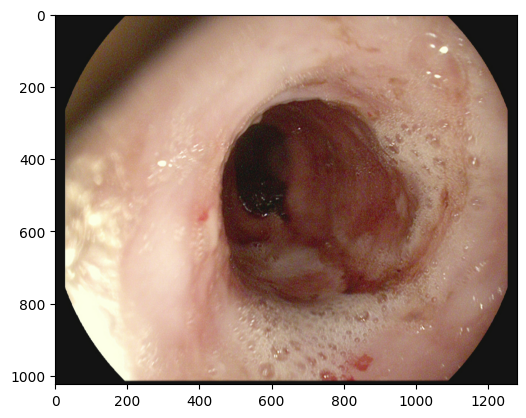

In [ ]:
# ReRun this block to generate for new ramdom sample
import random
sample = [val_dataset[random.randint(0, len(val_dataset)-1)]] # rerun this block to generate new sample
import matplotlib.pyplot as plt; plt.imshow(sample[0]['image'])
inputs = collate_fn(sample)
inputs = {k: v.to(device) for k, v in inputs.items() if k not in ['labels', 'attention_mask']}

with torch.no_grad():
    output = model_hf.generate(**inputs)

print(f"Q: {sample[0]['question']}\nModel: {processor.tokenizer.decode(output[0], skip_special_tokens=True)}\nGT: {sample[0]['answer']}")

Q: What type of polyp is present?
Model: none
GT: none


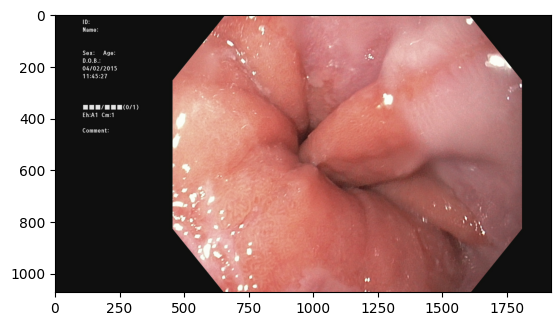

In [ ]:
# ReRun this block to generate for new ramdom sample
import random
sample = [val_dataset[random.randint(0, len(val_dataset)-1)]] # rerun this block to generate new sample
import matplotlib.pyplot as plt; plt.imshow(sample[0]['image'])
inputs = collate_fn(sample)
inputs = {k: v.to(device) for k, v in inputs.items() if k not in ['labels', 'attention_mask']}

with torch.no_grad():
    output = model_hf.generate(**inputs)

print(f"Q: {sample[0]['question']}\nModel: {processor.tokenizer.decode(output[0], skip_special_tokens=True)}\nGT: {sample[0]['answer']}")

Q: Where in the image is the anatomical landmark?
Model: none
GT: none


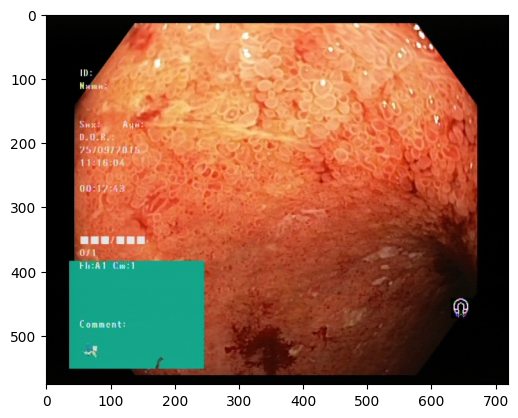

In [ ]:
# ReRun this block to generate for new ramdom sample
import random
sample = [val_dataset[random.randint(0, len(val_dataset)-1)]] # rerun this block to generate new sample
import matplotlib.pyplot as plt; plt.imshow(sample[0]['image'])
inputs = collate_fn(sample)
inputs = {k: v.to(device) for k, v in inputs.items() if k not in ['labels', 'attention_mask']}

with torch.no_grad():
    output = model_hf.generate(**inputs)

print(f"Q: {sample[0]['question']}\nModel: {processor.tokenizer.decode(output[0], skip_special_tokens=True)}\nGT: {sample[0]['answer']}")

Q: What type of polyp is present?
Model: none
GT: none


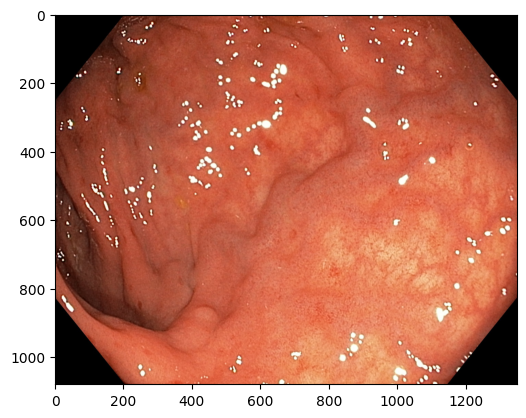

In [ ]:
# ReRun this block to generate for new ramdom sample
import random
sample = [val_dataset[random.randint(0, len(val_dataset)-1)]] # rerun this block to generate new sample
import matplotlib.pyplot as plt; plt.imshow(sample[0]['image'])
inputs = collate_fn(sample)
inputs = {k: v.to(device) for k, v in inputs.items() if k not in ['labels', 'attention_mask']}

with torch.no_grad():
    output = model_hf.generate(**inputs)

print(f"Q: {sample[0]['question']}\nModel: {processor.tokenizer.decode(output[0], skip_special_tokens=True)}\nGT: {sample[0]['answer']}")

Q: What color is the abnormality? If more than one separate with ;
Model: pink; red; white
GT: flesh; white; red


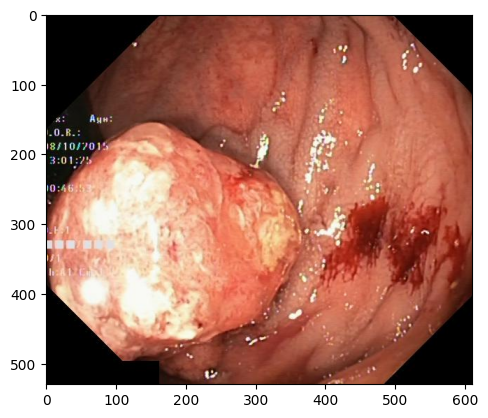

In [ ]:
# ReRun this block to generate for new ramdom sample
import random
sample = [val_dataset[random.randint(0, len(val_dataset)-1)]] # rerun this block to generate new sample
import matplotlib.pyplot as plt; plt.imshow(sample[0]['image'])
inputs = collate_fn(sample)
inputs = {k: v.to(device) for k, v in inputs.items() if k not in ['labels', 'attention_mask']}

with torch.no_grad():
    output = model_hf.generate(**inputs)

print(f"Q: {sample[0]['question']}\nModel: {processor.tokenizer.decode(output[0], skip_special_tokens=True)}\nGT: {sample[0]['answer']}")

In [ ]:
from transformers import AutoModelForCausalLM
from datasets import load_dataset
from transformers import AutoProcessor
import torch
import json
import time
from tqdm import tqdm
import subprocess
import platform
import sys

from evaluate import load

bleu = load("bleu")
rouge = load("rouge")
meteor = load("meteor")


val_dataset = load_dataset("SimulaMet/Kvasir-VQA-test", split="validation")
predictions = []  # List to store predictions

gpu_name = torch.cuda.get_device_name(
    0) if torch.cuda.is_available() else "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"


def get_mem(): return torch.cuda.memory_allocated(device) / \
    (1024 ** 2) if torch.cuda.is_available() else 0


initial_mem = get_mem()

# ✏️✏️--------EDIT SECTION 1: SUBMISISON DETAILS and MODEL LOADING --------✏️✏️#

SUBMISSION_INFO = {
    # 🔹 TODO: PARTICIPANTS MUST ADD PROPER SUBMISSION INFO FOR THE SUBMISSION 🔹
    # This will be visible to the organizers
    # DONT change the keys, only add your info
    "Participant_Names": "Ejiga Peter Ojonugwa, Md Mahmudur  Rahman",
    "Affiliations": "Morgan State University",
    "Contact_emails": ["ojeji1@morgan.edu", "md.rahman@morgan.edu"],
    # But, the first email only will be used for correspondance
    "Team_Name": "Morgan_CS",
    "Country": "USA",
    "Notes_to_organizers": '''
        Work In Progress
        '''
}
# 🔹 TODO: PARTICIPANTS MUST LOAD THEIR MODEL HERE, EDIT AS NECESSARY FOR YOUR MODEL 🔹
# can add necessary library imports here

model_hf = AutoModelForCausalLM.from_pretrained(
    "sageofai/Florence-2-full-finetune", trust_remote_code=True).to(device)
processor = AutoProcessor.from_pretrained(
    "microsoft/Florence-2-base-ft", trust_remote_code=True)

model_hf.eval()  # Ensure model is in evaluation mode
# 🏁----------------END  SUBMISISON DETAILS and MODEL LOADING -----------------🏁#

start_time, post_model_mem = time.time(), get_mem()
total_time, final_mem = round(
    time.time() - start_time, 4), round(get_mem() - post_model_mem, 2)
model_mem_used = round(post_model_mem - initial_mem, 2)

for idx, ex in enumerate(tqdm(val_dataset, desc="Validating")):
    question = ex["question"]
    image = ex["image"].convert(
        "RGB") if ex["image"].mode != "RGB" else ex["image"]
    # you have access to 'question' and 'image' variables for each example

# ✏️✏️___________EDIT SECTION 2: ANSWER GENERATION___________✏️✏️#
    # 🔹 TODO: PARTICIPANTS CAN MODIFY THIS TOKENIZATION STEP IF NEEDED 🔹
    inputs = processor(text=[question], images=[image],
                       return_tensors="pt", padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()
              if k not in ['labels', 'attention_mask']}

    # 🔹 TODO: PARTICIPANTS CAN MODIFY THE GENERATION AND DECODING METHOD HERE 🔹
    with torch.no_grad():
        output = model_hf.generate(**inputs)
    answer = processor.tokenizer.decode(output[0], skip_special_tokens=True)
    # make sure 'answer' variable will hold answer (sentence/word) as str
# 🏁________________ END ANSWER GENERATION ________________🏁#

# ⛔ DO NOT EDIT any lines below from here, can edit only upto decoding step above as required. ⛔
    # Ensures answer is a string
    assert isinstance(
        answer, str), f"Generated answer at index {idx} is not a string"
    # Appends prediction
    predictions.append(
        {"index": idx, "img_id": ex["img_id"], "question": ex["question"], "answer": answer})

# Ensure all predictions match dataset length
assert len(predictions) == len(
    val_dataset), "Mismatch between predictions and dataset length"

total_time, final_mem = round(
    time.time() - start_time, 4), round(get_mem() - post_model_mem, 2)
model_mem_used = round(post_model_mem - initial_mem, 2)

# caulcualtes metrics
references = [[e] for e in val_dataset['answer']]
preds = [pred['answer'] for pred in predictions]

bleu_result = bleu.compute(predictions=preds, references=references)
rouge_result = rouge.compute(predictions=preds, references=references)
meteor_result = meteor.compute(predictions=preds, references=references)
bleu_score = round(bleu_result['bleu'], 2)
rouge1_score = round(float(rouge_result['rouge1']), 2)
rouge2_score = round(float(rouge_result['rouge2']), 2)
rougeL_score = round(float(rouge_result['rougeL']), 2)
meteor_score = round(float(meteor_result['meteor']), 2)

public_scores = {
    'bleu': bleu_score,
    'rouge1': rouge1_score,
    'rouge2': rouge2_score,
    'rougeL': rougeL_score,
    'meteor': meteor_score
}
print("✨Public scores: ", public_scores)

# Saves predictions to a JSON file

output_data = {"submission_info": SUBMISSION_INFO, "public_scores": public_scores,
               "predictions": predictions, "total_time": total_time, "time_per_item": total_time / len(val_dataset),
               "memory_used_mb": final_mem, "model_memory_mb": model_mem_used, "gpu_name": gpu_name,
               "debug": {
                   "packages": json.loads(subprocess.check_output([sys.executable, "-m", "pip", "list", "--format=json"])),
                   "system": {
                       "python": platform.python_version(),
                       "os": platform.system(),
                       "platform": platform.platform(),
                       "arch": platform.machine()
                   }}}


with open("predictions_1.json", "w") as f:
    json.dump(output_data, f, indent=4)
print(f"Time: {total_time}s | Mem: {final_mem}MB | Model Load Mem: {model_mem_used}MB | GPU: {gpu_name}")
print("✅ Scripts Looks Good! Generation process completed successfully. Results saved to 'predictions_1.json'.")
print("Next Step:\n 1) Upload this submission_task1.py script file to HuggingFace model repository.")
print('''\n 2) Make a submission to the competition:\n Run:: medvqa validate_and_submit --competition=gi-2025 --task=1 --repo_id=...''')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


README.md:   0%|          | 0.00/442 [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/37.1M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/1384 [00:00<?, ? examples/s]

Validating: 100%|██████████| 1384/1384 [01:32<00:00, 14.90it/s]


✨Public scores:  {'bleu': 0.23, 'rouge1': 0.85, 'rouge2': 0.11, 'rougeL': 0.84, 'meteor': 0.46}
Time: 92.8985s | Mem: 0.0MB | Model Load Mem: 3.08MB | GPU: NVIDIA H100 NVL
✅ Scripts Looks Good! Generation process completed successfully. Results saved to 'predictions_1.json'.
Next Step:
 1) Upload this submission_task1.py script file to HuggingFace model repository.

 2) Make a submission to the competition:
 Run:: medvqa validate_and_submit --competition=gi-2025 --task=1 --repo_id=...



[notice] A new release of pip is available: 23.3.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [ ]:
!pip install -U medvqa

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.6/181.6 kB 110.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.3.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [ ]:
!medvqa validate --competition=gi-2025 --task=1 --repo_id=sageofai/Florence-2-full-finetune

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


🌟 ImageCLEFmed-MEDVQA-GI-2025 🌟 https://github.com/simula/ImageCLEFmed-MEDVQA-GI-2025
🔍 Subtask 1: Algorithm Development for Question Interpretation and Response
👀 Analyzing submission repository: sageofai/Florence-2-full-finetune 👀
Logged in to HuggingFace as: sageofai
Loaded as API: https://simulamet-medvqa.hf.space ✔
💓 Communicating with the Submission Server: Ping!
Pong! Submission server is alive! 😊
Fetching 2 files:   0%|                                   | 0/2 [00:00<?, ?it/s]
requirements.txt: 100%|███████████████████████| 13.0/13.0 [00:00<00:00, 222kB/s]
Fetching 2 files: 100%|███████████████████████████| 2/2 [00:00<00:00, 28.77it/s]
📦 Making sure of the minimum requirements to run the script 📦

[notice] A new release of pip is available: 23.3.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip
📦 Installing requirements from the submission repo: sageofai/Florence-2-full-finetune/requirements.txt

[notice] A new release of pip is available: 23.3.1 -> 25.1.1

In [ ]:
!medvqa validate_and_submit --competition=gi-2025 --task=1 --repo_id=sageofai/Florence-2-full-finetune

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


🌟 ImageCLEFmed-MEDVQA-GI-2025 🌟 https://github.com/simula/ImageCLEFmed-MEDVQA-GI-2025
🔍 Subtask 1: Algorithm Development for Question Interpretation and Response
👀 Analyzing submission repository: sageofai/Florence-2-full-finetune 👀
Logged in to HuggingFace as: sageofai
Loaded as API: https://simulamet-medvqa.hf.space ✔
💓 Communicating with the Submission Server: Ping!
Pong! Submission server is alive! 😊
Fetching 2 files: 100%|████████████████████████| 2/2 [00:00<00:00, 14691.08it/s]
📦 Making sure of the minimum requirements to run the script 📦

[notice] A new release of pip is available: 23.3.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip
📦 Installing requirements from the submission repo: sageofai/Florence-2-full-finetune/requirements.txt

[notice] A new release of pip is available: 23.3.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is alrea